# Chapter 8: Simplicial Homology

**Source orientation:** Armstrong, *Basic Topology*, Chapter 8, printed pp. 173-194; PDF pp. 182-202.

## Chapter Goal

Simplicial homology turns a triangulated space into boundary matrices. The visible objects are vertices, edges, triangles, and higher simplexes; the computable objects are chain groups, kernels, images, quotient groups, and ranks.

The guiding question is:

> Which closed chains detect holes, and which closed chains are only boundaries of higher-dimensional chains?

## Computational Translation Guide

| Chapter language | Computational object | Inspection target | Check |
| --- | --- | --- | --- |
| Oriented simplex | Ordered tuple of vertices | Arrow direction and sign | Reversing orientation flips a column |
| Chain group `C_q(K)` | Integer vectors indexed by `q`-simplexes | Matrix basis labels | Dimension equals simplex count |
| Boundary map `partial_q` | Integer matrix `D_q` | Alternating signs | `D_{q-1} @ D_q == 0` |
| Cycle group `Z_q` | Kernel of `D_q` | Closed edge sums | Rank-nullity |
| Boundary group `B_q` | Image of `D_{q+1}` | Filled regions | Rank of next boundary |
| Homology group `H_q` | Quotient `Z_q / B_q` | Cycles not killed by fillings | `beta_q = dim C_q - rank D_q - rank D_{q+1}` |
| Subdivision and maps | Chain maps commuting with boundary | Internal cancellation | Betti and Euler checks |

## Standalone Reading Guide

This notebook treats simplicial homology as a computational version of the question, Which holes survive after we declare filled-in pieces to be trivial? The geometric objects are finite simplicial complexes: vertices, edges, triangles, and higher-dimensional simplexes glued along faces. The algebraic objects are free abelian groups with one basis vector for each oriented simplex. The bridge between the two worlds is the boundary operator. An oriented edge has a signed endpoint boundary; an oriented triangle has a signed edge boundary; a tetrahedron has a signed triangle boundary. Once every simplex has been converted into a basis vector, the boundary operator becomes an integer matrix.

The central invariant is built in two stages. First, cycles are chains with zero boundary: they close up with no exposed edge, endpoint, or face. Second, boundaries are cycles that already arise as the boundary of a higher-dimensional chain. Homology remembers cycles only after quotienting out boundaries. This distinction is why the same drawn loop can mean different things in different complexes. A loop around a hollow triangle is a genuine one-dimensional hole. The same loop in a filled triangle is the boundary of the two-simplex, so it becomes trivial in homology.

The visual order follows that logic. The first figures establish orientation and sign conventions so the boundary matrix has a geometric meaning. The hollow-versus-filled comparison then shows how adding a simplex changes the image of the next boundary map without changing the visible edge loop. The Betti-number table translates kernels and images into dimensions of homology groups, while the Euler-characteristic ledger checks that alternating simplex counts and alternating Betti numbers agree for these finite examples. The subdivision section is included because homology must be about the underlying space, not the particular triangulation used to draw it.

The code cells deliberately keep the matrices small. They are meant to be inspectable enough that you can change an edge orientation, add a face, or delete a simplex and immediately predict which rank or nullity should change. The final sanity checks are not decorative tests; they encode the chapter's proof obligations in executable form. Boundary squared must be zero, ranks must obey rank-nullity, independent computations should agree on Betti numbers, and subdivision should preserve homology. Read those checks as miniature proofs that the diagrams and computations are talking about the same topological invariant.


One useful habit is to name every quotient before computing it. The chain group C_q records all formal q-dimensional pieces. The cycle group Z_q is the kernel of the boundary from C_q to C_{q-1}. The boundary group B_q is the image of the next boundary from C_{q+1} to C_q. The homology group H_q = Z_q / B_q therefore asks which closed q-dimensional chains are not already explained as the boundary of something one dimension higher. Each artifact in this chapter marks one step in that narrowing process: from all chains, to closed chains, to closed chains modulo filled-in ones.


This is also why the examples avoid very large complexes. A small complex makes the sign convention, matrix rank, displayed cycle, and topological interpretation visible at the same time. After those pieces agree, the same methods scale to larger triangulations where the matrices are too big to understand by sight but still carry the same geometric meaning.


In [1]:
from pathlib import Path
import itertools
import json
import sys

import gudhi as gd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import display


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "Basic-Topology"]:
            if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("Basic-Topology book root not found")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact

UNIT = "chapter-08"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "html"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

artifact_paths, check_paths, table_paths = [], [], []


def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def remember(path, bucket=artifact_paths):
    path = Path(path)
    bucket.append(path)
    return path


def write_json(data, path):
    path = Path(path)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return remember(path, check_paths)


def canonical(simplex):
    return tuple(sorted(int(v) for v in simplex))


def closure(maximal_simplices):
    faces = set()
    for simplex in maximal_simplices:
        simplex = canonical(simplex)
        for r in range(1, len(simplex) + 1):
            faces.update(tuple(face) for face in itertools.combinations(simplex, r))
    return sorted(faces, key=lambda s: (len(s), s))


def by_dim(maximal_simplices, max_dim=None):
    result = {}
    for simplex in closure(maximal_simplices):
        result.setdefault(len(simplex) - 1, []).append(simplex)
    if max_dim is not None:
        for q in range(max_dim + 1):
            result.setdefault(q, [])
    return result


def boundary_matrix(q_simplices, lower_simplices):
    q_simplices = [canonical(s) for s in q_simplices]
    lower_simplices = [canonical(s) for s in lower_simplices]
    lower_index = {s: i for i, s in enumerate(lower_simplices)}
    matrix = np.zeros((len(lower_simplices), len(q_simplices)), dtype=int)
    for col, simplex in enumerate(q_simplices):
        for i in range(len(simplex)):
            face = simplex[:i] + simplex[i + 1 :]
            matrix[lower_index[face], col] = -1 if i % 2 else 1
    return matrix


def exact_rank(matrix):
    matrix = np.asarray(matrix, dtype=int)
    return 0 if matrix.size == 0 else int(sp.Matrix(matrix.tolist()).rank())


def nullity(matrix):
    matrix = np.asarray(matrix, dtype=int)
    return int(matrix.shape[1] - exact_rank(matrix))


def homology_summary(maximal_simplices, max_dim=2):
    simplices = by_dim(maximal_simplices, max_dim=max_dim)
    D = {0: np.zeros((0, len(simplices[0])), dtype=int)}
    for q in range(1, max_dim + 1):
        D[q] = boundary_matrix(simplices[q], simplices[q - 1])
    betti = {}
    rows = []
    for q in range(max_dim + 1):
        n_q = len(simplices[q])
        rank_out = exact_rank(D[q]) if q else 0
        rank_in = exact_rank(D[q + 1]) if q + 1 <= max_dim else 0
        betti[q] = int(n_q - rank_out - rank_in)
        rows.append(
            {
                "q": q,
                "simplices": n_q,
                "rank_D_q": rank_out,
                "nullity_D_q": n_q - rank_out,
                "rank_D_q_plus_1": rank_in,
                "betti_q": betti[q],
            }
        )
    counts = {q: len(simplices[q]) for q in range(max_dim + 1)}
    chi_simplices = int(sum(((-1) ** q) * counts[q] for q in range(max_dim + 1)))
    chi_betti = int(sum(((-1) ** q) * betti[q] for q in range(max_dim + 1)))
    return {"simplices": simplices, "D": D, "betti": betti, "rows": rows, "counts": counts, "chi_simplices": chi_simplices, "chi_betti": chi_betti}


def gudhi_betti(maximal_simplices, max_dim=2):
    st = gd.SimplexTree()
    for simplex in maximal_simplices:
        st.insert(list(canonical(simplex)), filtration=0.0)
    st.persistence(homology_coeff_field=2, min_persistence=0, persistence_dim_max=True)
    raw = st.betti_numbers()
    return [int(raw[q]) if q < len(raw) else 0 for q in range(max_dim + 1)]


def label(simplex):
    if len(simplex) == 1:
        return f"v{simplex[0]}"
    if len(simplex) == 2:
        return "e" + "".join(map(str, simplex))
    return "t" + "".join(map(str, simplex))


def plot_matrix(ax, matrix, row_labels, col_labels, title):
    matrix = np.asarray(matrix, dtype=int)
    vmax = max(1, int(np.abs(matrix).max())) if matrix.size else 1
    ax.imshow(matrix, cmap="coolwarm", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, str(int(matrix[i, j])), ha="center", va="center", fontsize=9)
    ax.tick_params(length=0)


def draw_complex(ax, coords, edges, triangles=(), title="", highlight_edges=(), fill_color="#d8f3dc"):
    highlights = {canonical(edge) for edge in highlight_edges}
    for tri in triangles:
        pts = np.array([coords[v] for v in tri])
        ax.add_patch(Polygon(pts, closed=True, facecolor=fill_color, edgecolor="none", alpha=0.72))
    for edge in edges:
        a, b = edge
        pa, pb = np.array(coords[a]), np.array(coords[b])
        color = "#c1121f" if canonical(edge) in highlights else "#24292f"
        width = 2.7 if canonical(edge) in highlights else 1.3
        ax.plot([pa[0], pb[0]], [pa[1], pb[1]], color=color, lw=width)
    for v, point in coords.items():
        ax.scatter([point[0]], [point[1]], s=52, color="white", edgecolor="#24292f", zorder=4)
        ax.text(point[0], point[1] + 0.055, f"v{v}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")


def arrow_edge(ax, coords, edge, color="#c1121f"):
    a, b = edge
    pa, pb = np.array(coords[a], dtype=float), np.array(coords[b], dtype=float)
    direction = pb - pa
    ax.add_patch(FancyArrowPatch(pa + 0.08 * direction, pb - 0.08 * direction, arrowstyle="-|>", mutation_scale=14, lw=1.8, color=color))


def orientation_sign(sequence, sorted_sequence=None):
    seq = list(sequence)
    target = list(sorted_sequence if sorted_sequence is not None else sorted(sequence))
    positions = [target.index(x) for x in seq]
    inversions = sum(1 for i in range(len(positions)) for j in range(i + 1, len(positions)) if positions[i] > positions[j])
    return -1 if inversions % 2 else 1


BOOK_ROOT

WindowsPath('D:/Geometry/Basic-Topology')

## Proof Roadmap

The chapter's logic is a chain of implications: orientations give chain groups, chain groups give boundary matrices, the identity `D_{q-1}D_q=0` puts boundaries inside cycles, and the quotient `Z_q/B_q` records the cycles that remain. The diagram is a proof scaffold for the computations below.

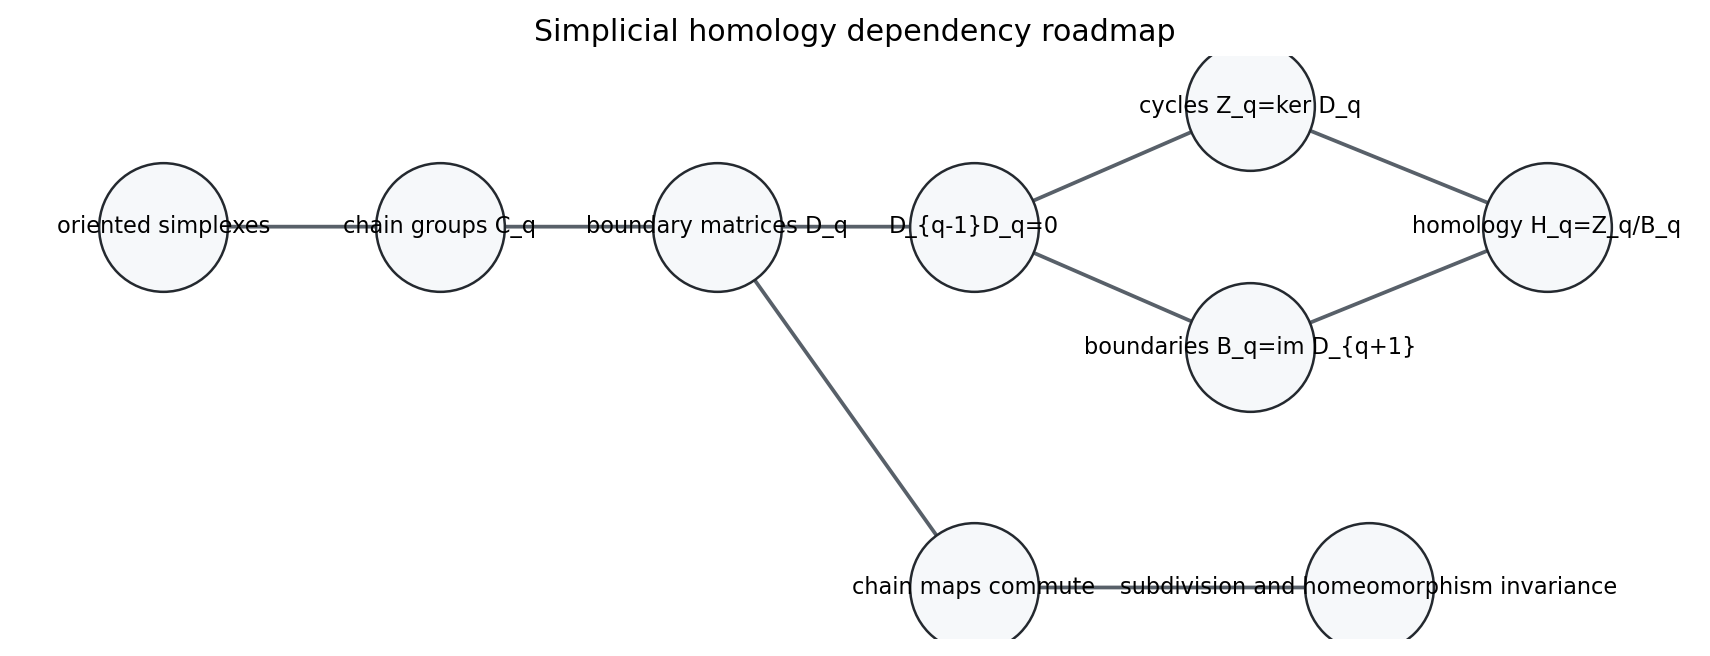

In [2]:
roadmap = nx.DiGraph()
roadmap.add_edges_from(
    [
        ("oriented simplexes", "chain groups C_q"),
        ("chain groups C_q", "boundary matrices D_q"),
        ("boundary matrices D_q", "D_{q-1}D_q=0"),
        ("D_{q-1}D_q=0", "cycles Z_q=ker D_q"),
        ("D_{q-1}D_q=0", "boundaries B_q=im D_{q+1}"),
        ("cycles Z_q=ker D_q", "homology H_q=Z_q/B_q"),
        ("boundaries B_q=im D_{q+1}", "homology H_q=Z_q/B_q"),
        ("boundary matrices D_q", "chain maps commute"),
        ("chain maps commute", "subdivision and homeomorphism invariance"),
    ]
)
pos = {
    "oriented simplexes": (0, 0.5),
    "chain groups C_q": (1.4, 0.5),
    "boundary matrices D_q": (2.8, 0.5),
    "D_{q-1}D_q=0": (4.1, 0.5),
    "cycles Z_q=ker D_q": (5.5, 0.85),
    "boundaries B_q=im D_{q+1}": (5.5, 0.15),
    "homology H_q=Z_q/B_q": (7.0, 0.5),
    "chain maps commute": (4.1, -0.55),
    "subdivision and homeomorphism invariance": (6.1, -0.55),
}
fig, ax = plt.subplots(figsize=(12, 4.2))
nx.draw_networkx_edges(roadmap, pos, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.5, edge_color="#586069", ax=ax)
nx.draw_networkx_nodes(roadmap, pos, node_color="#f6f8fa", edgecolors="#24292f", node_size=2650, ax=ax)
nx.draw_networkx_labels(roadmap, pos, font_size=9, ax=ax)
ax.set_title("Simplicial homology dependency roadmap")
ax.axis("off")
roadmap_path = remember(FIG_DIR / "chain-complex-proof-roadmap.png")
fig.savefig(roadmap_path, dpi=180, bbox_inches="tight")
plt.close(fig)
write_json({"artifact": rel(roadmap_path), "nodes": roadmap.number_of_nodes(), "edges": roadmap.number_of_edges(), "is_dag": nx.is_directed_acyclic_graph(roadmap)}, CHECK_DIR / "chain-complex-proof-roadmap-checks.json")
assert nx.is_directed_acyclic_graph(roadmap)
display_artifact(roadmap_path, width=900)

## 1. Boundary Matrices From One Oriented Triangle

For the oriented triangle `(0,1,2)`, the edge basis is `(0,1)`, `(0,2)`, `(1,2)`. The matrix `D_2` is the column vector for `(1,2) - (0,2) + (0,1)`. Multiplying by `D_1` proves that the boundary of this boundary is zero.

,e01,e02,e12
v0,-1,-1,0
v1,1,0,-1
v2,0,1,1


,t012
e01,1
e02,-1
e12,1


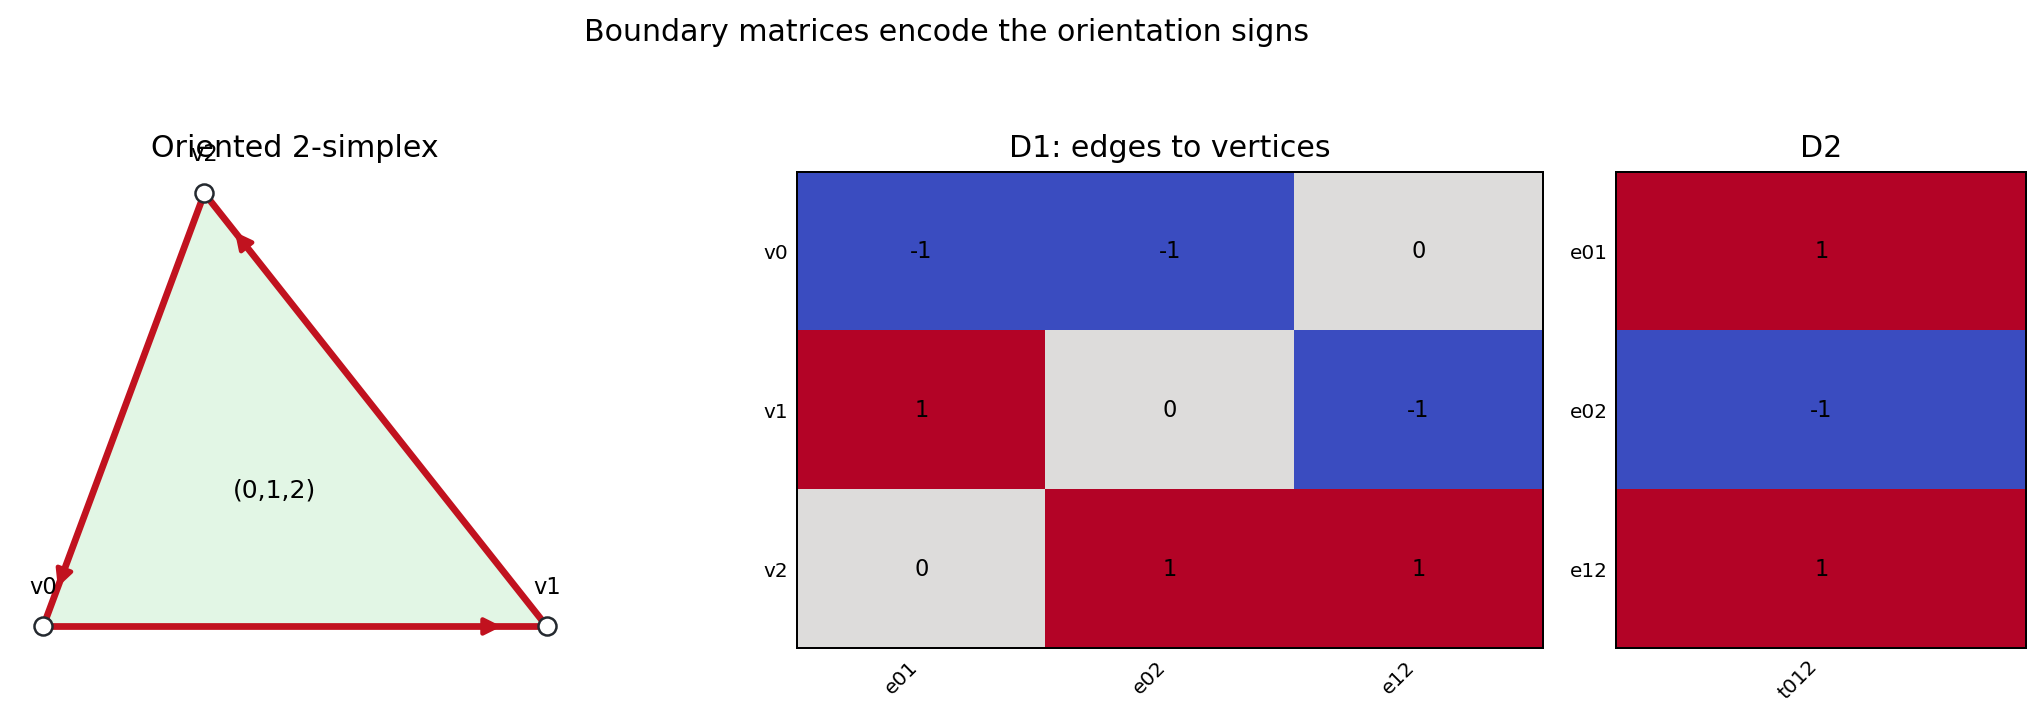

In [3]:
triangle = [(0, 1, 2)]
tri = homology_summary(triangle)
verts, edges, faces = tri["simplices"][0], tri["simplices"][1], tri["simplices"][2]
D1, D2 = tri["D"][1], tri["D"][2]
coords = {0: np.array([0.0, 0.0]), 1: np.array([1.0, 0.0]), 2: np.array([0.32, 0.86])}

D1_df = pd.DataFrame(D1, index=[label(v) for v in verts], columns=[label(e) for e in edges])
D2_df = pd.DataFrame(D2, index=[label(e) for e in edges], columns=[label(t) for t in faces])
D1_csv = TABLE_DIR / "oriented-triangle-D1.csv"
D1_df.to_csv(D1_csv)
remember(D1_csv, table_paths)
D2_csv = TABLE_DIR / "oriented-triangle-D2.csv"
D2_df.to_csv(D2_csv)
remember(D2_csv, table_paths)

fig, axes = plt.subplots(1, 3, figsize=(12.3, 3.8), gridspec_kw={"width_ratios": [1.15, 1, 0.55]})
draw_complex(axes[0], coords, edges, faces, "Oriented 2-simplex", edges)
for edge in [(0, 1), (1, 2), (2, 0)]:
    arrow_edge(axes[0], coords, edge)
axes[0].text(0.46, 0.27, "(0,1,2)", ha="center", va="center", fontsize=10)
plot_matrix(axes[1], D1, [label(v) for v in verts], [label(e) for e in edges], "D1: edges to vertices")
plot_matrix(axes[2], D2, [label(e) for e in edges], ["t012"], "D2")
fig.suptitle("Boundary matrices encode the orientation signs", y=1.04)
fig.tight_layout()
boundary_path = remember(FIG_DIR / "oriented-simplex-boundary-matrices.png")
fig.savefig(boundary_path, dpi=180, bbox_inches="tight")
plt.close(fig)

write_json(
    {"artifact": rel(boundary_path), "D1": D1.tolist(), "D2": D2.tolist(), "D1_times_D2": (D1 @ D2).tolist(), "rank_D1": exact_rank(D1), "rank_D2": exact_rank(D2), "boundary_squared_zero": bool(np.array_equal(D1 @ D2, np.zeros((3, 1), dtype=int)))},
    CHECK_DIR / "oriented-simplex-boundary-checks.json",
)
assert np.array_equal(D1 @ D2, np.zeros((3, 1), dtype=int))
display(D1_df)
display(D2_df)
display_artifact(boundary_path, width=900)

## 2. Cycles Versus Boundaries

The chain `(0,1) - (0,2) + (1,2)` is closed in both a hollow triangle and a filled triangle. The difference is the next boundary map. In the hollow triangle there is no 2-chain to fill it, so it survives in `H_1`. In the filled triangle it is exactly the boundary of the 2-simplex, so it represents zero in `H_1`.

,complex,dim_Z1,rank_B1,beta1,chi
0,hollow triangle,1,0,1,0
1,filled triangle,1,1,0,1


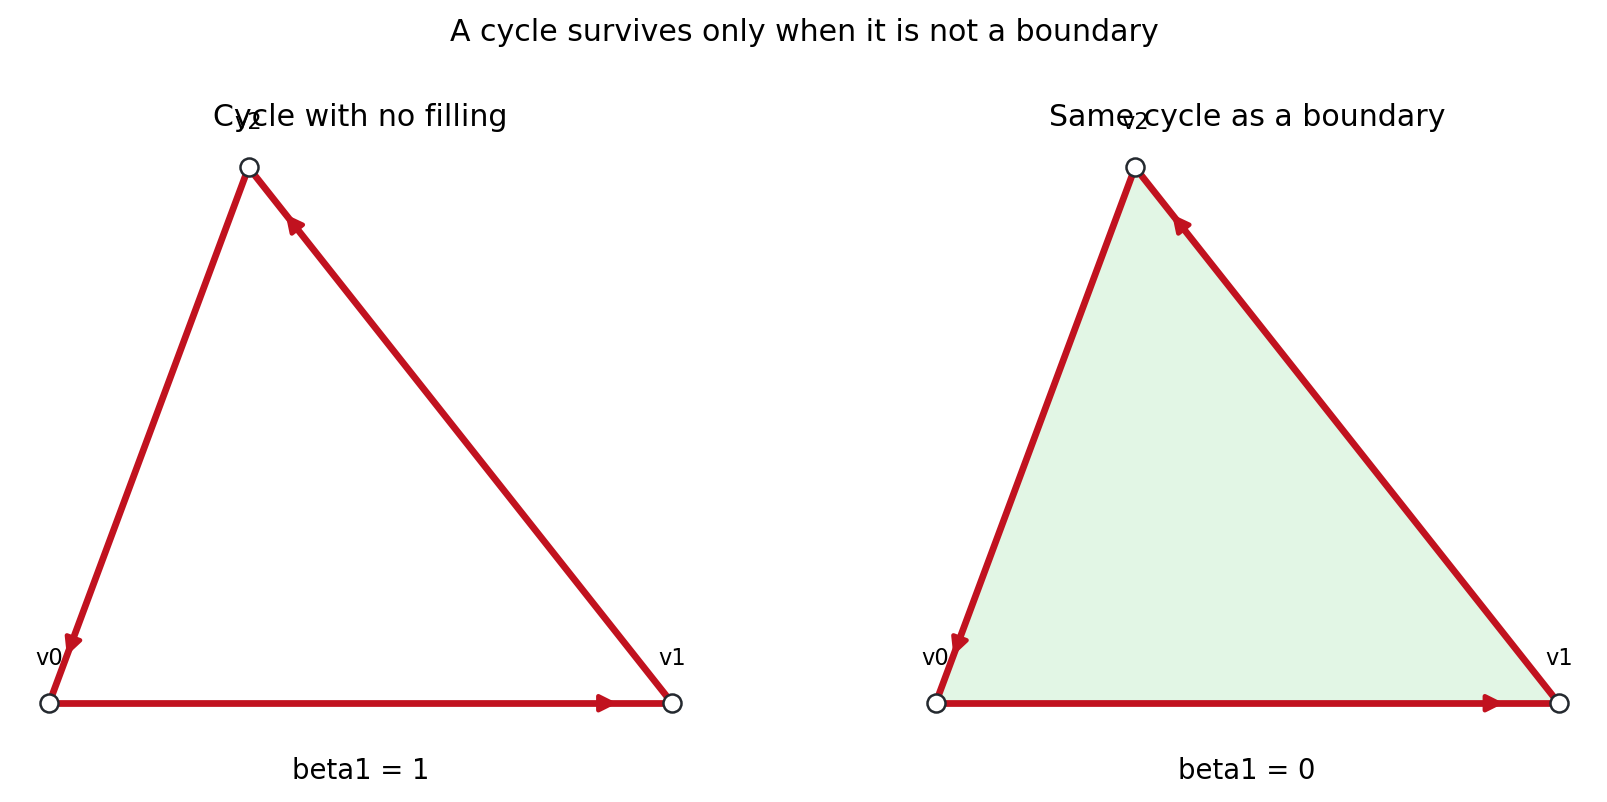

In [4]:
hollow = [(0, 1), (0, 2), (1, 2)]
filled = [(0, 1, 2)]
hollow_sum = homology_summary(hollow)
filled_sum = homology_summary(filled)
cycle_vec = np.array([1, -1, 1], dtype=int)
hollow_cycle = np.array_equal(hollow_sum["D"][1] @ cycle_vec, np.zeros(3, dtype=int))
filled_cycle = np.array_equal(filled_sum["D"][1] @ cycle_vec, np.zeros(3, dtype=int))
fill_solution = sp.Matrix(filled_sum["D"][2]).gauss_jordan_solve(sp.Matrix(cycle_vec))[0]
cycle_df = pd.DataFrame(
    [
        {"complex": "hollow triangle", "dim_Z1": nullity(hollow_sum["D"][1]), "rank_B1": exact_rank(hollow_sum["D"][2]), "beta1": hollow_sum["betti"][1], "chi": hollow_sum["chi_simplices"]},
        {"complex": "filled triangle", "dim_Z1": nullity(filled_sum["D"][1]), "rank_B1": exact_rank(filled_sum["D"][2]), "beta1": filled_sum["betti"][1], "chi": filled_sum["chi_simplices"]},
    ]
)
cycle_csv = TABLE_DIR / "cycle-versus-boundary.csv"
cycle_df.to_csv(cycle_csv, index=False)
remember(cycle_csv, table_paths)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
draw_complex(axes[0], coords, hollow_sum["simplices"][1], [], "Cycle with no filling", edges)
draw_complex(axes[1], coords, filled_sum["simplices"][1], filled_sum["simplices"][2], "Same cycle as a boundary", edges)
for ax in axes:
    for edge in [(0, 1), (2, 0), (1, 2)]:
        arrow_edge(ax, coords, edge)
axes[0].text(0.5, -0.12, "beta1 = 1", ha="center", fontsize=11)
axes[1].text(0.5, -0.12, "beta1 = 0", ha="center", fontsize=11)
fig.suptitle("A cycle survives only when it is not a boundary", y=1.02)
fig.tight_layout()
cycle_path = remember(FIG_DIR / "cycle-versus-boundary.png")
fig.savefig(cycle_path, dpi=180, bbox_inches="tight")
plt.close(fig)

write_json(
    {"artifact": rel(cycle_path), "edge_basis": [label(e) for e in edges], "cycle_vector": cycle_vec.tolist(), "hollow_is_cycle": bool(hollow_cycle), "filled_is_cycle": bool(filled_cycle), "filled_boundary_solution": [str(x) for x in list(fill_solution)], "hollow_beta1": hollow_sum["betti"][1], "filled_beta1": filled_sum["betti"][1]},
    CHECK_DIR / "cycle-versus-boundary-checks.json",
)
assert hollow_cycle and filled_cycle
assert hollow_sum["betti"][1] == 1 and filled_sum["betti"][1] == 0
display(cycle_df)
display_artifact(cycle_path, width=850)

## 3. Homology Groups, Betti Numbers, And Euler Characteristic

The rank formula below computes the free part of each homology group. Gudhi provides an independent topology-library check over field coefficients. These examples are torsion-free, so the Gudhi Betti numbers agree with the integer free ranks.

,complex,n0,n1,n2,rank_D1,rank_D2,beta0,beta1,beta2,gudhi_beta0,gudhi_beta1,gudhi_beta2,chi_simplices,chi_betti,gudhi_matches
0,interval,2,1,0,1,0,1,0,0,1,0,0,1,1,True
1,circle boundary,3,3,0,2,0,1,1,0,1,1,0,0,0,True
2,filled triangle,3,3,1,2,1,1,0,0,1,0,0,1,1,True
3,wedge of two circles,5,6,0,4,0,1,2,0,1,2,0,-1,-1,True
4,tetrahedron boundary,4,6,4,3,3,1,0,1,1,0,1,2,2,True


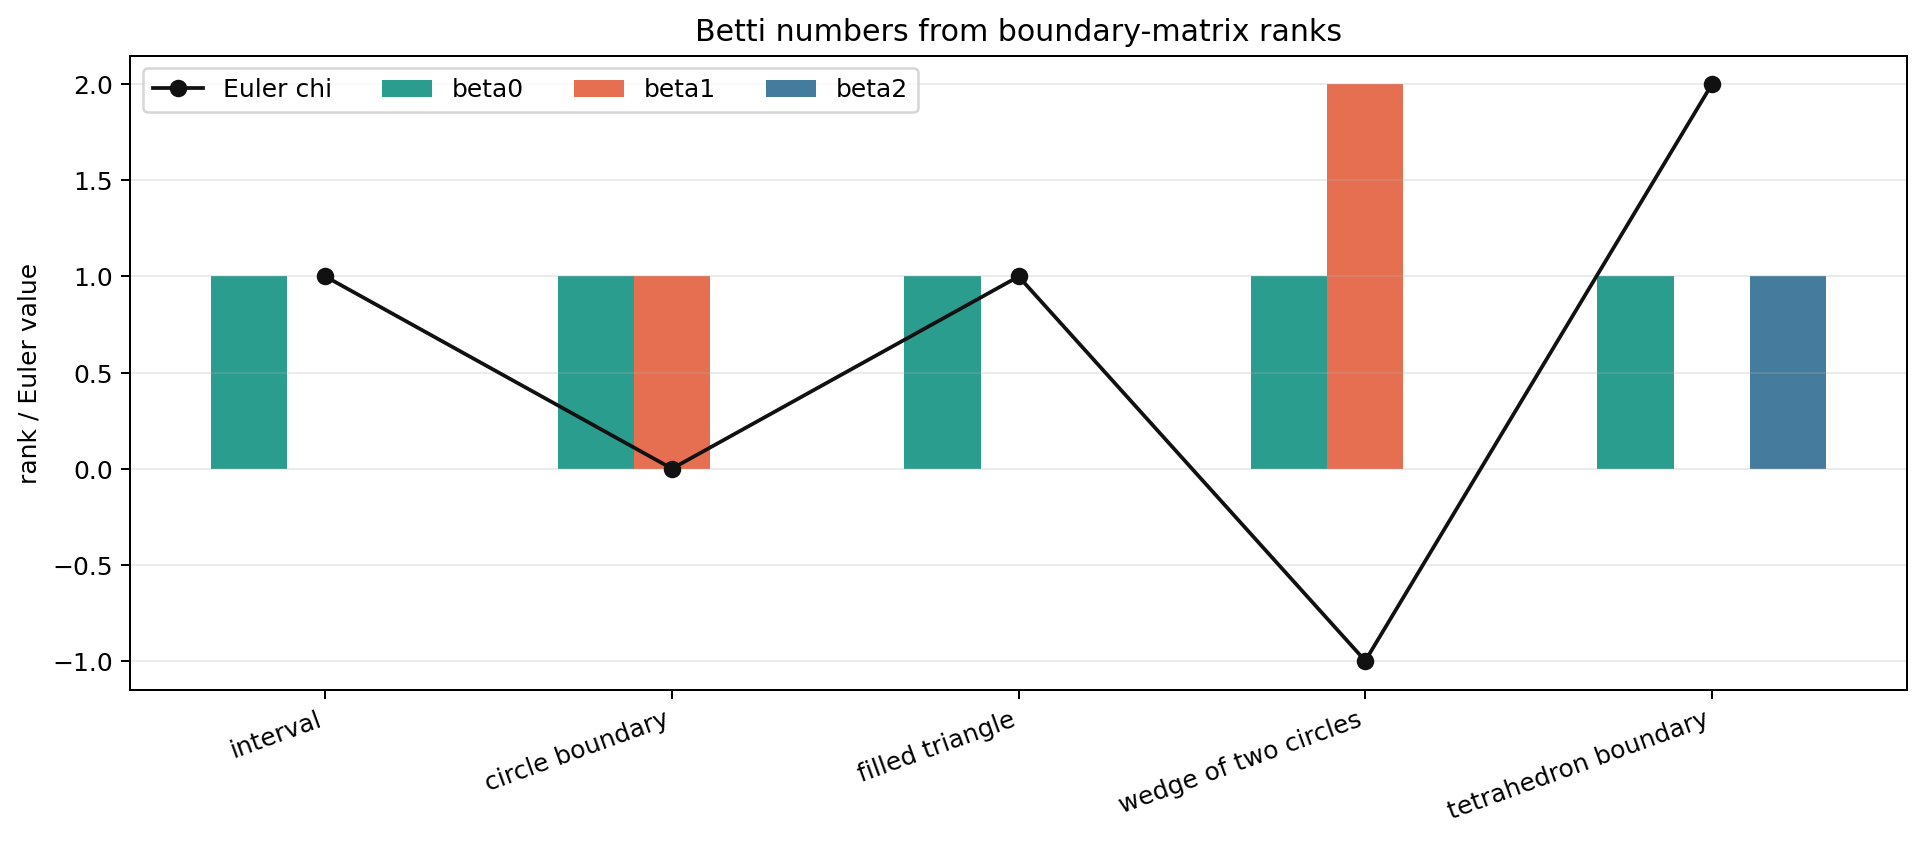

In [5]:
examples = {
    "interval": [(0, 1)],
    "circle boundary": [(0, 1), (0, 2), (1, 2)],
    "filled triangle": [(0, 1, 2)],
    "wedge of two circles": [(0, 1), (1, 2), (0, 2), (0, 3), (3, 4), (0, 4)],
    "tetrahedron boundary": [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)],
}
summaries = {name: homology_summary(maximal) for name, maximal in examples.items()}
rows = []
for name, maximal in examples.items():
    summary = summaries[name]
    gbetti = gudhi_betti(maximal)
    row = {
        "complex": name,
        "n0": summary["counts"][0],
        "n1": summary["counts"][1],
        "n2": summary["counts"][2],
        "rank_D1": exact_rank(summary["D"][1]),
        "rank_D2": exact_rank(summary["D"][2]),
        "beta0": summary["betti"][0],
        "beta1": summary["betti"][1],
        "beta2": summary["betti"][2],
        "gudhi_beta0": gbetti[0],
        "gudhi_beta1": gbetti[1],
        "gudhi_beta2": gbetti[2],
        "chi_simplices": summary["chi_simplices"],
        "chi_betti": summary["chi_betti"],
    }
    row["gudhi_matches"] = [row["beta0"], row["beta1"], row["beta2"]] == gbetti
    rows.append(row)
examples_df = pd.DataFrame(rows)
examples_csv = TABLE_DIR / "homology-examples-rank-betti-euler.csv"
examples_df.to_csv(examples_csv, index=False)
remember(examples_csv, table_paths)

fig, ax = plt.subplots(figsize=(10.8, 4.8))
x = np.arange(len(examples_df))
width = 0.22
for offset, q, color in [(-width, 0, "#2a9d8f"), (0, 1, "#e76f51"), (width, 2, "#457b9d")]:
    ax.bar(x + offset, examples_df[f"beta{q}"], width=width, label=f"beta{q}", color=color)
ax.plot(x, examples_df["chi_simplices"], color="#111111", marker="o", lw=1.5, label="Euler chi")
ax.set_xticks(x)
ax.set_xticklabels(examples_df["complex"], rotation=20, ha="right")
ax.set_ylabel("rank / Euler value")
ax.set_title("Betti numbers from boundary-matrix ranks")
ax.legend(ncol=4, loc="upper left")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
betti_png = remember(FIG_DIR / "homology-examples-betti-euler.png")
fig.savefig(betti_png, dpi=180, bbox_inches="tight")
plt.close(fig)

pfig = go.Figure()
for q, color in [(0, "#2a9d8f"), (1, "#e76f51"), (2, "#457b9d")]:
    pfig.add_trace(go.Bar(name=f"beta{q}", x=examples_df["complex"], y=examples_df[f"beta{q}"], marker_color=color))
pfig.add_trace(go.Scatter(name="Euler chi", x=examples_df["complex"], y=examples_df["chi_simplices"], mode="lines+markers", line=dict(color="#111111")))
pfig.update_layout(title="Homology ranks and Euler characteristic", barmode="group", template="plotly_white", xaxis_title="finite complex", yaxis_title="value", legend_orientation="h")
betti_html = remember(HTML_DIR / "homology-examples-betti-euler.html")
pfig.write_html(betti_html, include_plotlyjs=True, full_html=True)

write_json(
    {"artifacts": [rel(betti_png), rel(betti_html)], "rows": rows, "all_boundary_squared_zero": all(np.array_equal(s["D"][1] @ s["D"][2], np.zeros((s["D"][1].shape[0], s["D"][2].shape[1]), dtype=int)) for s in summaries.values()), "all_euler_checks_match": bool((examples_df["chi_simplices"] == examples_df["chi_betti"]).all()), "all_gudhi_matches": bool(examples_df["gudhi_matches"].all())},
    CHECK_DIR / "homology-examples-checks.json",
)
assert (examples_df["chi_simplices"] == examples_df["chi_betti"]).all()
assert examples_df["gudhi_matches"].all()
display(examples_df)
display_artifact(betti_png, width=900)
display_artifact(betti_html, width="100%", height=430)

## 4. Subdivision And Simplicial Maps

Subdivision changes the combinatorial model, not the space. In a barycentric subdivision of a triangle, internal edges occur twice with opposite signs in the boundary of the subdivided 2-chain. A simplicial homeomorphism gives another invariance check: its chain matrices must commute with the boundary matrix.

,complex,beta0,beta1,beta2,chi
0,original triangle,1,0,0,1
1,subdivided triangle,1,0,0,1


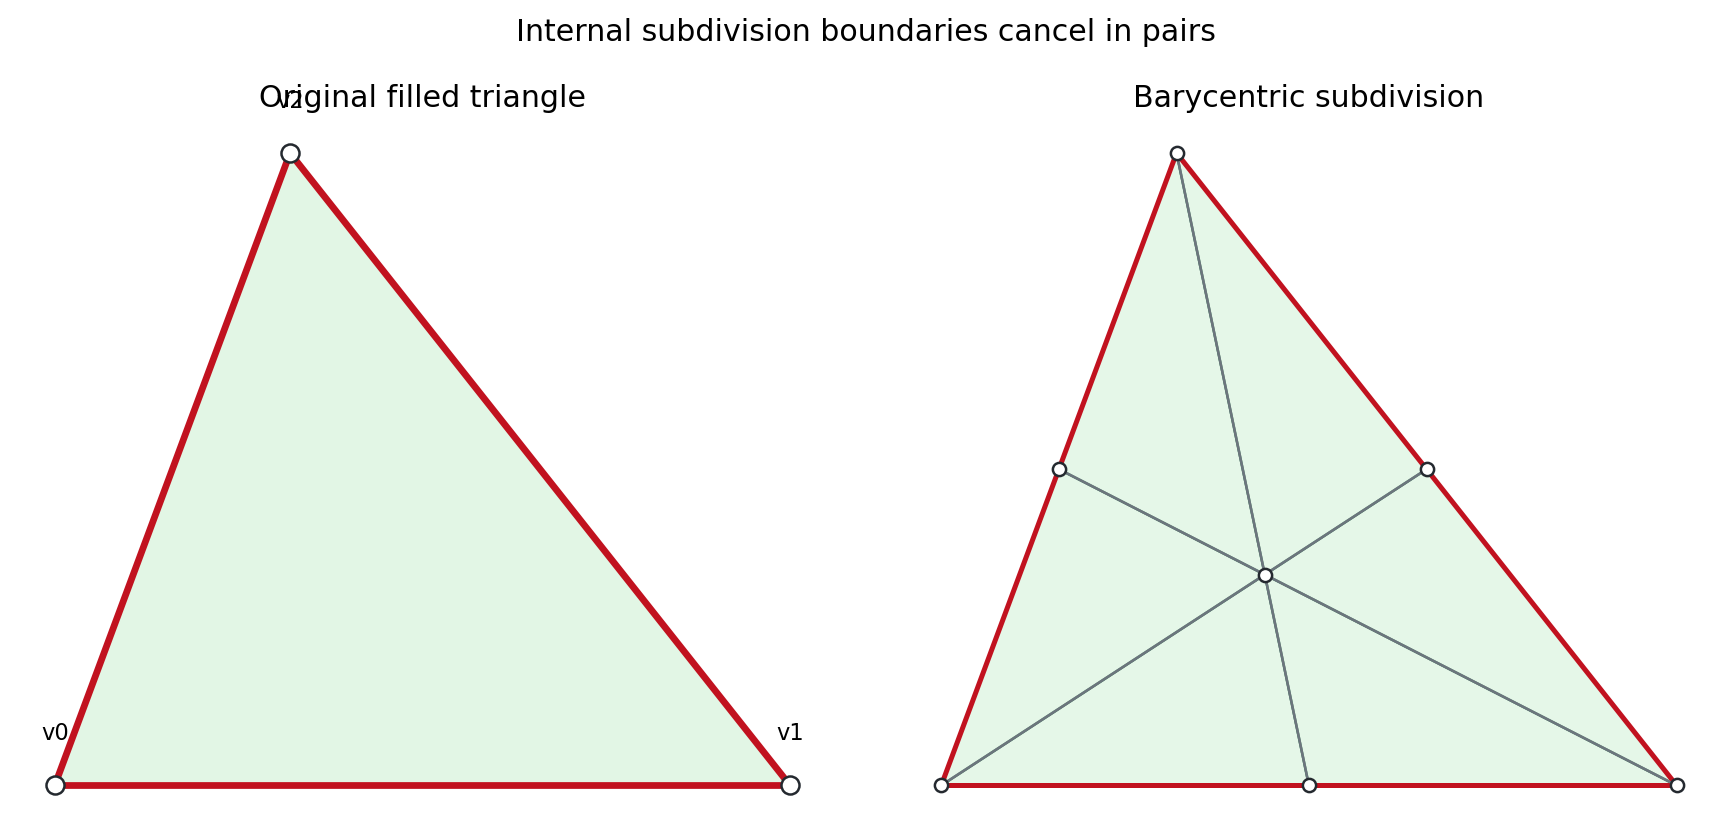

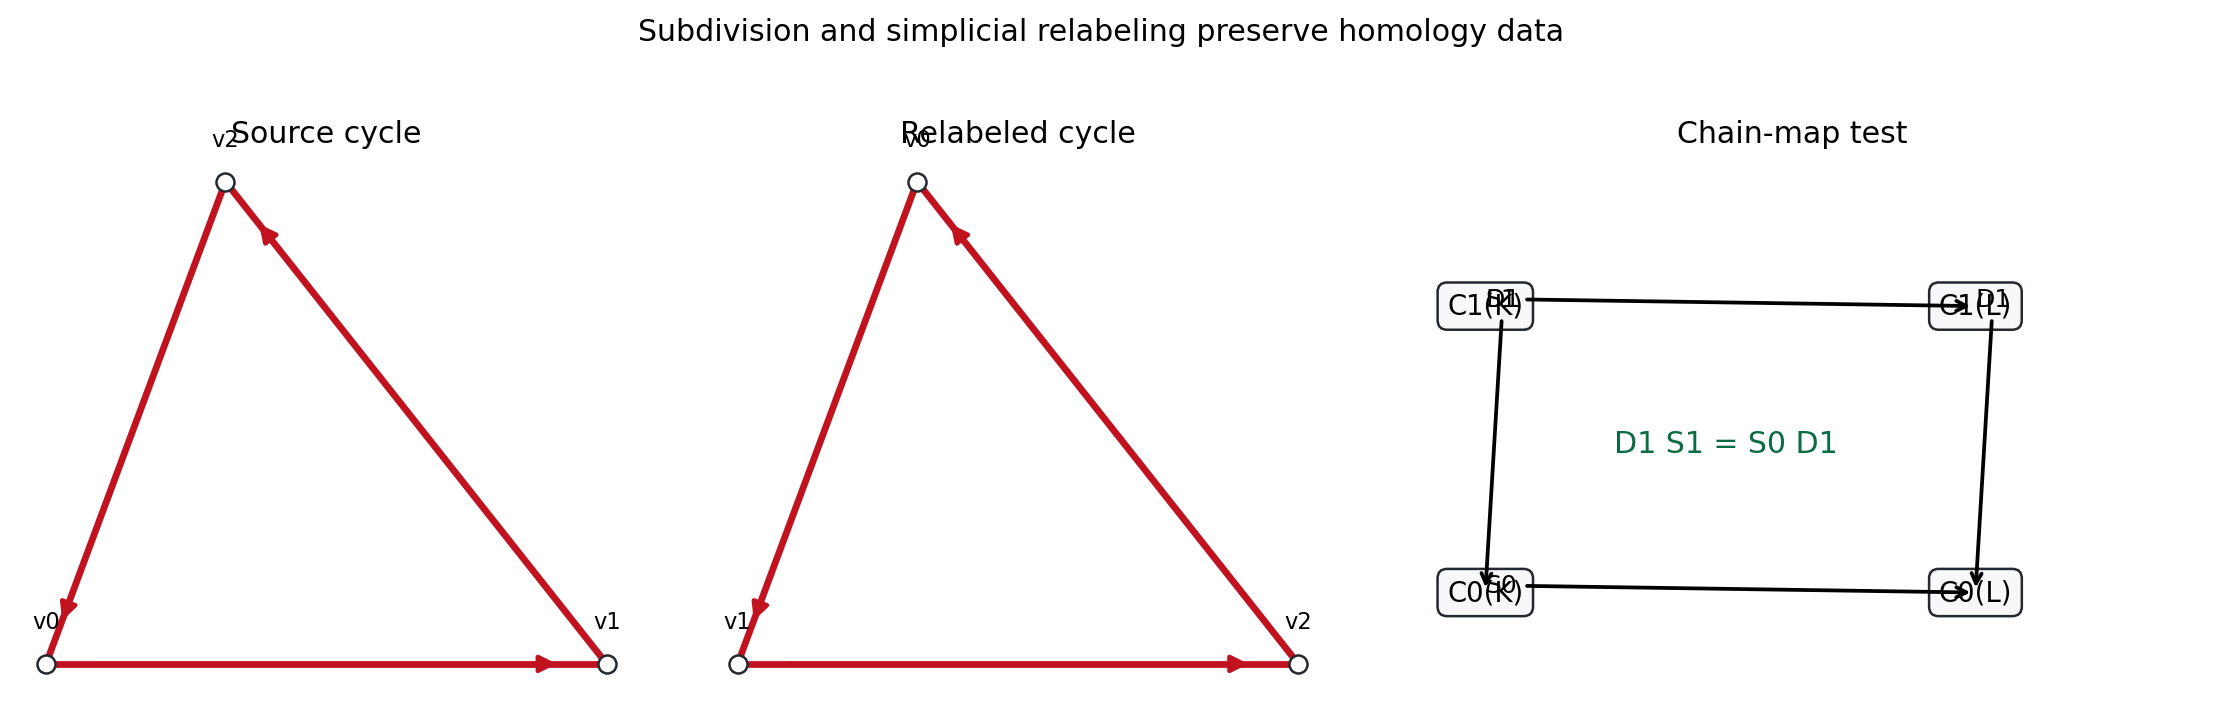

In [6]:
def barycentric_subdivision(maximal_simplices, old_coords):
    old_faces = closure(maximal_simplices)
    face_id = {face: i for i, face in enumerate(old_faces)}
    id_to_face = {i: face for face, i in face_id.items()}
    new_coords = {face_id[face]: np.mean([old_coords[v] for v in face], axis=0) for face in old_faces}
    new_maximal, signed_top_chain = [], []
    for simplex in [canonical(s) for s in maximal_simplices]:
        for perm in itertools.permutations(simplex):
            flag = tuple(face_id[canonical(perm[:k])] for k in range(1, len(perm) + 1))
            new_maximal.append(flag)
            signed_top_chain.append((flag, orientation_sign(perm, simplex)))
    return new_maximal, new_coords, id_to_face, signed_top_chain


sub_tris, sub_coords, id_to_face, signed_top = barycentric_subdivision(triangle, coords)
sub_sum = homology_summary(sub_tris)
tri_index = {t: i for i, t in enumerate(sub_sum["simplices"][2])}
coeff = np.zeros(len(sub_sum["simplices"][2]), dtype=int)
for simplex, sign in signed_top:
    coeff[tri_index[canonical(simplex)]] += sign
sub_boundary = sub_sum["D"][2] @ coeff
internal_rows, outer_rows = [], []
for i, edge in enumerate(sub_sum["simplices"][1]):
    sizes = sorted(len(id_to_face[v]) for v in edge)
    row = {"edge": edge, "face_sizes": sizes, "coefficient": int(sub_boundary[i])}
    (internal_rows if sizes == [2, 3] else outer_rows).append(row)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
draw_complex(axes[0], coords, edges, faces, "Original filled triangle", edges)
for tri_face in sub_tris:
    pts = np.array([sub_coords[v] for v in tri_face])
    axes[1].add_patch(Polygon(pts, closed=True, facecolor="#d8f3dc", edgecolor="#2d6a4f", alpha=0.65, linewidth=1.0))
for edge in sub_sum["simplices"][1]:
    pa, pb = sub_coords[edge[0]], sub_coords[edge[1]]
    sizes = sorted(len(id_to_face[v]) for v in edge)
    axes[1].plot([pa[0], pb[0]], [pa[1], pb[1]], color="#c1121f" if sizes == [1, 2] else "#6c757d", lw=2.0 if sizes == [1, 2] else 1.0)
for v, point in sub_coords.items():
    axes[1].scatter([point[0]], [point[1]], s=28, color="white", edgecolor="#24292f", zorder=4)
axes[1].set_title("Barycentric subdivision")
axes[1].set_aspect("equal")
axes[1].axis("off")
fig.suptitle("Internal subdivision boundaries cancel in pairs", y=1.02)
fig.tight_layout()
subdiv_png = remember(FIG_DIR / "subdivision-boundary-cancellation.png")
fig.savefig(subdiv_png, dpi=180, bbox_inches="tight")
plt.close(fig)

original_betti = [tri["betti"][q] for q in range(3)]
subdivided_betti = [sub_sum["betti"][q] for q in range(3)]
write_json(
    {"artifact": rel(subdiv_png), "original_counts": tri["counts"], "subdivided_counts": sub_sum["counts"], "original_betti": original_betti, "subdivided_betti": subdivided_betti, "original_euler": tri["chi_simplices"], "subdivided_euler": sub_sum["chi_simplices"], "internal_boundary_coefficients": internal_rows, "outer_boundary_coefficients": outer_rows, "internal_edges_cancel": all(row["coefficient"] == 0 for row in internal_rows), "betti_preserved": original_betti == subdivided_betti, "euler_preserved": tri["chi_simplices"] == sub_sum["chi_simplices"]},
    CHECK_DIR / "subdivision-boundary-cancellation-checks.json",
)
assert original_betti == subdivided_betti
assert all(row["coefficient"] == 0 for row in internal_rows)

def chain_map_matrix(source_simplices, target_simplices, vertex_map):
    target_index = {canonical(s): i for i, s in enumerate(target_simplices)}
    matrix = np.zeros((len(target_simplices), len(source_simplices)), dtype=int)
    for col, simplex in enumerate(source_simplices):
        image = tuple(vertex_map[v] for v in simplex)
        if len(set(image)) == len(image):
            target = canonical(image)
            matrix[target_index[target], col] = orientation_sign(image, target)
    return matrix

vertex_rotation = {0: 1, 1: 2, 2: 0}
S0 = chain_map_matrix(hollow_sum["simplices"][0], hollow_sum["simplices"][0], vertex_rotation)
S1 = chain_map_matrix(hollow_sum["simplices"][1], hollow_sum["simplices"][1], vertex_rotation)
commutator = hollow_sum["D"][1] @ S1 - S0 @ hollow_sum["D"][1]
cycle_image = S1 @ cycle_vec

fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.8), gridspec_kw={"width_ratios": [1, 1, 1.25]})
draw_complex(axes[0], coords, hollow_sum["simplices"][1], [], "Source cycle", hollow_sum["simplices"][1])
rot_coords = {vertex_rotation[k]: v for k, v in coords.items()}
draw_complex(axes[1], rot_coords, hollow_sum["simplices"][1], [], "Relabeled cycle", hollow_sum["simplices"][1])
for ax, arrows in [(axes[0], [(0, 1), (2, 0), (1, 2)]), (axes[1], [(1, 2), (0, 1), (2, 0)])]:
    for edge in arrows:
        arrow_edge(ax, coords if ax is axes[0] else rot_coords, edge)
axes[2].axis("off")
boxes = {"C1(K)": (0.13, 0.72), "C0(K)": (0.13, 0.18), "C1(L)": (0.72, 0.72), "C0(L)": (0.72, 0.18)}
for label_box, xy in boxes.items():
    axes[2].text(*xy, label_box, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.35", fc="#f6f8fa", ec="#24292f"), fontsize=11)
axes[2].annotate("S1", xy=boxes["C1(L)"], xytext=boxes["C1(K)"], arrowprops=dict(arrowstyle="->", lw=1.5))
axes[2].annotate("S0", xy=boxes["C0(L)"], xytext=boxes["C0(K)"], arrowprops=dict(arrowstyle="->", lw=1.5))
axes[2].annotate("D1", xy=boxes["C0(K)"], xytext=boxes["C1(K)"], arrowprops=dict(arrowstyle="->", lw=1.5))
axes[2].annotate("D1", xy=boxes["C0(L)"], xytext=boxes["C1(L)"], arrowprops=dict(arrowstyle="->", lw=1.5))
axes[2].text(0.42, 0.46, "D1 S1 = S0 D1", ha="center", va="center", fontsize=12, color="#0b6b43")
axes[2].set_title("Chain-map test")
fig.suptitle("Subdivision and simplicial relabeling preserve homology data", y=1.02)
fig.tight_layout()
map_png = remember(FIG_DIR / "simplicial-map-chain-map-commutes.png")
fig.savefig(map_png, dpi=180, bbox_inches="tight")
plt.close(fig)

write_json(
    {"artifact": rel(map_png), "S0": S0.tolist(), "S1": S1.tolist(), "D1_S1_minus_S0_D1": commutator.tolist(), "commutes_with_boundary": bool(np.array_equal(commutator, np.zeros_like(commutator))), "cycle_vector": cycle_vec.tolist(), "cycle_image": cycle_image.tolist(), "cycle_preserved": bool(np.array_equal(cycle_image, cycle_vec))},
    CHECK_DIR / "simplicial-map-chain-map-checks.json",
)
assert np.array_equal(commutator, np.zeros_like(commutator))
assert np.array_equal(cycle_image, cycle_vec)
display(pd.DataFrame([{"complex": "original triangle", "beta0": original_betti[0], "beta1": original_betti[1], "beta2": original_betti[2], "chi": tri["chi_simplices"]}, {"complex": "subdivided triangle", "beta0": subdivided_betti[0], "beta1": subdivided_betti[1], "beta2": subdivided_betti[2], "chi": sub_sum["chi_simplices"]}]))
display_artifact(subdiv_png, width=850)
display_artifact(map_png, width=900)

## Applied Lab: Killing Loops By Adding Boundaries

Start with two triangular loops sharing a vertex. As a graph it has two independent 1-cycles. Filling one triangular loop adds a 2-simplex, enlarges `B_1`, and drops `beta_1` by one. Filling both loops kills both visible 1-cycles.

,complex,n0,n1,n2,rank_D1,rank_D2,dim_Z1,rank_B1,beta0,beta1,beta2,chi_simplices,chi_betti
0,two cycles visible,5,6,0,4,0,2,0,1,2,0,-1,-1
1,left cycle filled,5,6,1,4,1,2,1,1,1,0,0,0
2,both cycles filled,5,6,2,4,2,2,2,1,0,0,1,1


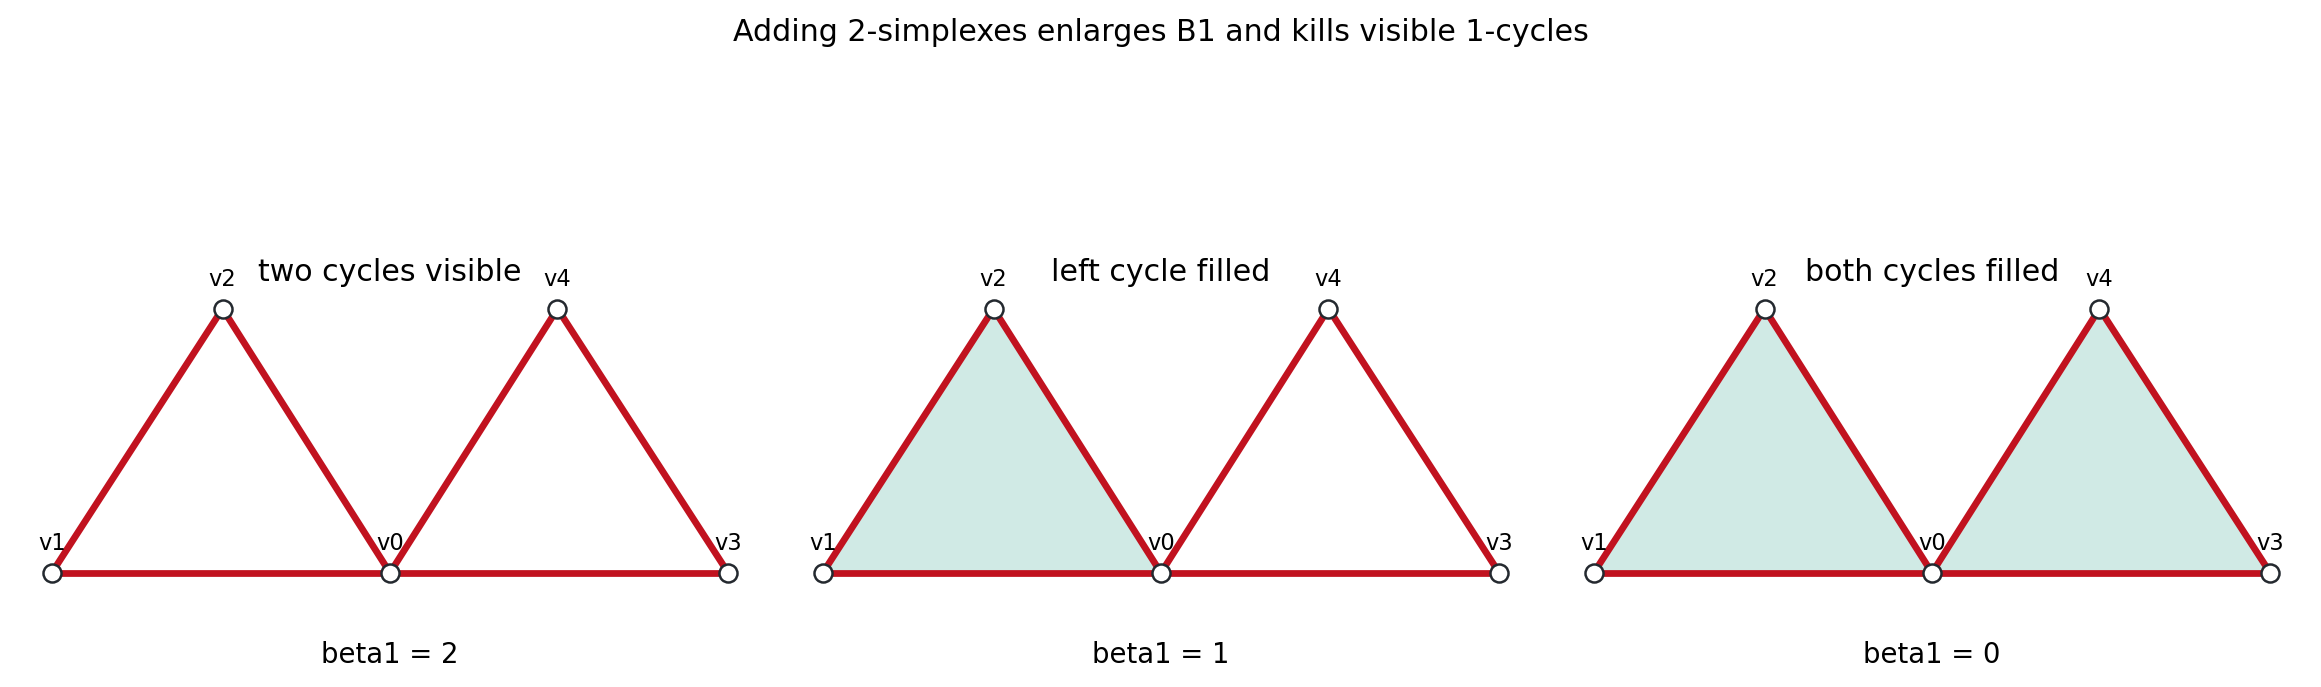

In [7]:
lab_complexes = {
    "two cycles visible": [(0, 1), (1, 2), (0, 2), (0, 3), (3, 4), (0, 4)],
    "left cycle filled": [(0, 1, 2), (0, 3), (3, 4), (0, 4)],
    "both cycles filled": [(0, 1, 2), (0, 3, 4)],
}
lab_coords = {0: np.array([0.0, 0.0]), 1: np.array([-1.05, 0.0]), 2: np.array([-0.52, 0.82]), 3: np.array([1.05, 0.0]), 4: np.array([0.52, 0.82])}
lab_rows = []
for name, maximal in lab_complexes.items():
    summary = homology_summary(maximal)
    lab_rows.append({"complex": name, "n0": summary["counts"][0], "n1": summary["counts"][1], "n2": summary["counts"][2], "rank_D1": exact_rank(summary["D"][1]), "rank_D2": exact_rank(summary["D"][2]), "dim_Z1": nullity(summary["D"][1]), "rank_B1": exact_rank(summary["D"][2]), "beta0": summary["betti"][0], "beta1": summary["betti"][1], "beta2": summary["betti"][2], "chi_simplices": summary["chi_simplices"], "chi_betti": summary["chi_betti"]})
lab_df = pd.DataFrame(lab_rows)
lab_csv = TABLE_DIR / "lab-killing-cycles-by-fillings.csv"
lab_df.to_csv(lab_csv, index=False)
remember(lab_csv, table_paths)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (name, maximal) in zip(axes, lab_complexes.items()):
    summary = homology_summary(maximal)
    draw_complex(ax, lab_coords, summary["simplices"][1], summary["simplices"][2], name, summary["simplices"][1], fill_color="#bee3db")
    ax.text(0.0, -0.28, f"beta1 = {summary['betti'][1]}", ha="center", fontsize=11)
fig.suptitle("Adding 2-simplexes enlarges B1 and kills visible 1-cycles", y=1.02)
fig.tight_layout()
lab_png = remember(FIG_DIR / "lab-killing-cycles-by-fillings.png")
fig.savefig(lab_png, dpi=180, bbox_inches="tight")
plt.close(fig)
write_json({"artifact": rel(lab_png), "rows": lab_rows, "beta1_sequence": lab_df["beta1"].astype(int).tolist(), "rank_B1_sequence": lab_df["rank_B1"].astype(int).tolist(), "euler_checks_match": bool((lab_df["chi_simplices"] == lab_df["chi_betti"]).all())}, CHECK_DIR / "lab-killing-cycles-by-fillings-checks.json")
assert lab_df["beta1"].tolist() == [2, 1, 0]
assert (lab_df["chi_simplices"] == lab_df["chi_betti"]).all()
display(lab_df)
display_artifact(lab_png, width=950)

## Final Sanity Checks

These checks close the loop: boundary-squared-zero, rank-nullity, Betti numbers, Euler characteristic, Gudhi cross-checks, subdivision invariance, chain-map commutation, lab behavior, and artifact integrity.

In [8]:
all_summaries = {"hollow triangle": hollow_sum, "filled triangle": filled_sum, **summaries, "subdivided triangle": sub_sum}
boundary_squared_zero = {}
rank_nullity = {}
for name, summary in all_summaries.items():
    D1_here, D2_here = summary["D"][1], summary["D"][2]
    product = D1_here @ D2_here
    boundary_squared_zero[name] = bool(np.array_equal(product, np.zeros_like(product)))
    for q, Dq in summary["D"].items():
        rank_nullity[f"{name}:D{q}"] = bool(exact_rank(Dq) + nullity(Dq) == Dq.shape[1])
euler = {name: bool(summary["chi_simplices"] == summary["chi_betti"]) for name, summary in all_summaries.items()}

artifact_sizes = {}
for path in artifact_paths:
    assert_artifact(path, min_bytes=1024 if path.suffix.lower() in {".png", ".html"} else 64)
    artifact_sizes[rel(path)] = path.stat().st_size
for path in check_paths + table_paths:
    assert_artifact(path, min_bytes=1)
    artifact_sizes[rel(path)] = path.stat().st_size

sanity = {
    "boundary_squared_zero": boundary_squared_zero,
    "rank_nullity": rank_nullity,
    "euler_characteristic": euler,
    "examples_gudhi_matches": bool(examples_df["gudhi_matches"].all()),
    "subdivision_betti_preserved": bool(original_betti == subdivided_betti),
    "subdivision_internal_edges_cancel": bool(all(row["coefficient"] == 0 for row in internal_rows)),
    "simplicial_map_commutes_with_boundary": bool(np.array_equal(commutator, np.zeros_like(commutator))),
    "lab_beta1_sequence": lab_df["beta1"].astype(int).tolist(),
    "artifact_sizes": artifact_sizes,
}
final_check = write_json(sanity, CHECK_DIR / "sanity-checks.json")
assert_artifact(final_check, min_bytes=512)

assert all(boundary_squared_zero.values())
assert all(rank_nullity.values())
assert all(euler.values())
assert sanity["examples_gudhi_matches"]
assert sanity["subdivision_betti_preserved"]
assert sanity["subdivision_internal_edges_cancel"]
assert sanity["simplicial_map_commutes_with_boundary"]
assert sanity["lab_beta1_sequence"] == [2, 1, 0]

pd.DataFrame(
    [
        {"check_family": "boundary_squared_zero", "passed": all(boundary_squared_zero.values())},
        {"check_family": "rank_nullity", "passed": all(rank_nullity.values())},
        {"check_family": "euler_characteristic", "passed": all(euler.values())},
        {"check_family": "gudhi_cross_check", "passed": sanity["examples_gudhi_matches"]},
        {"check_family": "subdivision", "passed": sanity["subdivision_betti_preserved"] and sanity["subdivision_internal_edges_cancel"]},
        {"check_family": "simplicial_map", "passed": sanity["simplicial_map_commutes_with_boundary"]},
        {"check_family": "artifact_integrity", "passed": all(size > 0 for size in artifact_sizes.values())},
    ]
)

,check_family,passed
0,boundary_squared_zero,True
1,rank_nullity,True
2,euler_characteristic,True
3,gudhi_cross_check,True
4,subdivision,True
5,simplicial_map,True
6,artifact_integrity,True


## Takeaways

- A chain is an integer vector on oriented simplexes.
- Boundary matrices are the central computational object: cycles are kernels, boundaries are images, and homology measures the part of the kernel not accounted for by the next image.
- The identity `D_{q-1}D_q = 0` is the reason `Z_q / B_q` is meaningful.
- Adding a 2-simplex can turn a visible loop into a boundary and remove its homology class.
- Subdivision changes the number of simplexes, but internal boundaries cancel and Betti numbers stay fixed.
- Simplicial maps that commute with boundary send cycles to cycles and boundaries to boundaries, which is the mechanism behind invariance.